# 05 — NDMM PBMC Subset Object Generation
### By [Mansi Singh](mansi.singh@alleninstitute.org), Comp Bio, Allen Institute for Immunology
**Aim:** Subset the QC-filtered PBMC object by L3 cell type, then run standard (PCA → UMAP) and Harmony-corrected processing for each subset. Outputs per-cell-type raw, processed, and harmonized AnnData files plus UMAP coordinates.



## 1 Imports

In [ ]:
import logging
import os
import shutil
from datetime import date, datetime

import hisepy as hp              # HISE platform utilities
import numpy as np               # Numerical computation
import pytz                      # Timezone conversion
import scanpy as sc              # Single-cell analysis
import scanpy.external as sce    # External integrations (Harmony)
from scipy.stats import median_abs_deviation
from tqdm import tqdm            # Progress bars
import matplotlib.pyplot as plt  # Static plotting
import seaborn as sns            # Statistical visualization
import pandas as pd              # DataFrames

sc.settings.n_jobs = 60
print("Current working directory:", os.getcwd())

# Suppress verbose logging from Harmony and Scanpy
logging.getLogger("harmonypy").setLevel(logging.WARNING)
logging.getLogger("scanpy").setLevel(logging.WARNING)

Current working directory: /home/workspace/MM_analysis


#### Necessary Paths

In [ ]:
# Output directories for per-cell-type objects and UMAP coordinates
ndmm_pbmc_celltype_dir = '../../../data/rna/ndmm-pbmc-celltypes/'
os.makedirs(ndmm_pbmc_celltype_dir, exist_ok=True)

ndmm_pbmc_umap_dir = '../../../data/rna/ndmm-pbmc-celltypes-umaps/'
os.makedirs(ndmm_pbmc_umap_dir, exist_ok=True)

### 1.2 Custom functions

In [ ]:
def is_outlier(adata, metric: str, nmads: int):
    """Flag cells whose metric is > nmads MADs from the median."""
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier


def process_adata(adata, harmony=False, harmony_key=None):
    """
    Standard scRNA-seq processing pipeline for a single cell-type subset.

    Steps: store raw counts → QC metrics → outlier flagging → normalize →
    log1p → HVG → scale → PCA → (optional Harmony) → neighbors → UMAP →
    Leiden → ranked genes.

    Parameters
    ----------
    adata : AnnData
        Raw counts matrix (cells × genes).
    harmony : bool
        If True, run Harmony batch correction before neighbors/UMAP.
    harmony_key : str or None
        obs column for Harmony integration (e.g., 'sample.sampleKitGuid').

    Returns
    -------
    adata : AnnData
        Processed object with embeddings, clusters, and ranked genes.
    """
    # Store raw counts layer
    adata.layers["counts"] = adata.X.copy()

    # Annotate gene categories for QC
    adata.var["mt"] = adata.var_names.str.startswith("MT-")        # Mitochondrial
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))  # Ribosomal
    adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")   # Hemoglobin

    # Calculate QC metrics
    sc.pp.calculate_qc_metrics(
        adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
    )

    # Flag outlier cells (5 MADs for counts/genes/top-20, 3 MADs for mito)
    adata.obs["outlier"] = (
        is_outlier(adata, "log1p_total_counts", 5)
        | is_outlier(adata, "log1p_n_genes_by_counts", 5)
        | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
    )
    adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
        adata.obs["pct_counts_mt"] >= 6  # Hard cap at 6% mito
    )
    # NOTE: Doublets and outliers already removed at the whole-object level (NB04);
    # outlier flags are computed here for reporting but not filtered again.

    # Normalization pipeline
    adata.raw = adata
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)

    # Highly variable gene selection
    sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.25)
    adata = adata[:, adata.var_names[adata.var["highly_variable"]]].copy()

    # Scale and PCA
    sc.pp.scale(adata, max_value=10, zero_center=False)
    sc.tl.pca(adata, svd_solver="arpack")
    adata.obsm["X_pca_temp"] = adata.obsm["X_pca"]

    # Optional: Harmony batch correction
    if harmony:
        sce.pp.harmony_integrate(adata, key=harmony_key)
        adata.obsm["X_pca"] = adata.obsm["X_pca_harmony"]

    # Neighborhood graph, UMAP, and clustering
    sc.pp.neighbors(adata, n_neighbors=50, use_rep="X_pca", n_pcs=20)
    sc.tl.umap(adata, min_dist=0.45, random_state=0, n_components=2)
    sc.tl.leiden(adata, resolution=1, n_iterations=2)

    # Ranked marker genes per Leiden cluster
    sc.tl.rank_genes_groups(
        adata, "leiden", method="t-test",
        key_added="t-test", use_raw=False, layer="counts",
    )

    return adata

## 2 Get the raw object

In [ ]:
# Load QC-filtered object produced in notebook 04
adata = sc.read_h5ad('../../../data/rna/output_QC/MM_pbmc_initial_qc_2025-06-20.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 2944774 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'aifi_l1', 'aifi_l2', 'aifi_l3', 'predicted_doublet', 'doublet_score', 'sample.sampleKitGuid', 'sample.visitDetails', 'sample.visitName', 'sample.drawDate', 'sample.daysSinceFirstVisit', 'sample.diseaseStatesRecordedAtVisit', 'subject.biologicalSex', 'subject.birthYear', 'subject.ethnicity', 'subject.partnerCode', 'subject.race', 'subject.subjectGuid', 'cohort.cohortGuid', 'manual.time_stamp', 'manual.tissue', 'manual.disease_condition', 'manual.response', 'manual.response_type', 'manual.extracted_name', 'manual.file_paths', 'manual.batch_id', 'manual.cmv.ab_screen_index_value', 'manual.cmv.ab_screen_result', 'manual.cmv.ab_visit', 'manual.igg.iga', 'manual.igg.ig

## 3 Process cell types

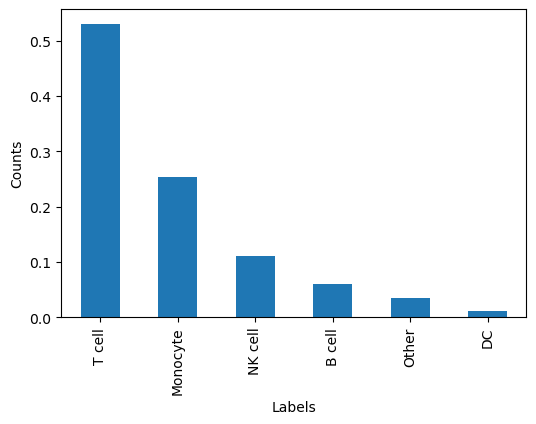

In [ ]:
# L1 cell-type proportions in the QC-filtered object
plt.style.use('default')
plt.figure(figsize=(6, 4))
adata.obs['tidy.aifi_l1'].value_counts(normalize=True).plot(kind='bar')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.show()

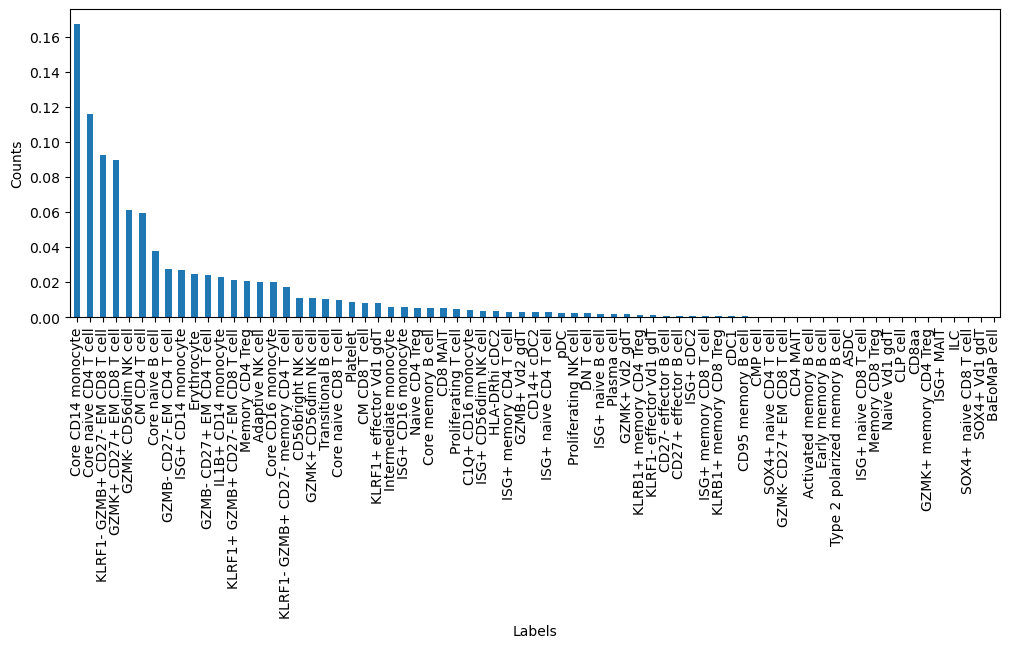

In [ ]:
# L3 cell-type proportions (finer resolution)
plt.style.use('default')
plt.figure(figsize=(12, 4))
adata.obs['tidy.aifi_l3'].value_counts(normalize=True).plot(kind='bar')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.show()

In [ ]:
# Get L3 cell types sorted by frequency (ascending → process rare types first)
groups = list(adata.obs['tidy.aifi_l3'].value_counts().index)
groups.reverse()
print(f"{len(groups)} L3 cell types to process")

['BaEoMaP cell',
 'SOX4+ Vd1 gdT',
 'SOX4+ naive CD8 T cell',
 'ILC',
 'ISG+ MAIT',
 'GZMK+ memory CD4 Treg',
 'CD8aa',
 'CLP cell',
 'Naive Vd1 gdT',
 'Memory CD8 Treg',
 'ISG+ naive CD8 T cell',
 'ASDC',
 'Type 2 polarized memory B cell',
 'Early memory B cell',
 'Activated memory B cell',
 'CD4 MAIT',
 'GZMK- CD27+ EM CD8 T cell',
 'SOX4+ naive CD4 T cell',
 'CMP cell',
 'CD95 memory B cell',
 'cDC1',
 'KLRB1+ memory CD8 Treg',
 'ISG+ memory CD8 T cell',
 'ISG+ cDC2',
 'CD27+ effector B cell',
 'CD27- effector B cell',
 'KLRF1- effector Vd1 gdT',
 'KLRB1+ memory CD4 Treg',
 'GZMK+ Vd2 gdT',
 'Plasma cell',
 'ISG+ naive B cell',
 'DN T cell',
 'Proliferating NK cell',
 'pDC',
 'ISG+ naive CD4 T cell',
 'CD14+ cDC2',
 'GZMB+ Vd2 gdT',
 'ISG+ memory CD4 T cell',
 'HLA-DRhi cDC2',
 'ISG+ CD56dim NK cell',
 'C1Q+ CD16 monocyte',
 'Proliferating T cell',
 'CD8 MAIT',
 'Core memory B cell',
 'Naive CD4 Treg',
 'ISG+ CD16 monocyte',
 'Intermediate monocyte',
 'KLRF1+ effector Vd1 gdT',
 'CM

In [ ]:
for group in groups:

    group_name = group.replace(" ", "").lower()
    file_save_name = f"{str(date.today())}-ndmm-pbmc-{group_name}-celltype"
    print("Processing:", file_save_name)

    # Subset QC-filtered adata by L3 cell type
    # FIX: was `adata_ms` — undefined variable; should be `adata`
    sub_adata = adata[adata.obs["tidy.aifi_l3"] == group]

    # Save raw subset
    print("  Saving raw object:", group)
    sub_adata.write(ndmm_pbmc_celltype_dir + file_save_name + "-raw.h5ad")

    # --- Standard processing (no batch correction) ---
    sub_adata_processed = process_adata(sub_adata)
    print("  Saving processed object:", group)
    sub_adata_processed.write(ndmm_pbmc_celltype_dir + file_save_name + "-processed.h5ad")

    # Export UMAP coordinates
    umap_coords = pd.DataFrame(
        sub_adata_processed.obsm["X_umap"],
        index=sub_adata_processed.obs.index,
        columns=["UMAP1", "UMAP2"],
    )
    umap_coords.to_csv(ndmm_pbmc_umap_dir + file_save_name + "-processed-umap.csv")

    # --- Harmony-corrected processing (batch = sample kit) ---
    sub_adata_processed = process_adata(
        sub_adata, harmony=True, harmony_key="sample.sampleKitGuid"
    )
    sub_adata_processed.write(
        ndmm_pbmc_celltype_dir + file_save_name + "-harmony-processed.h5ad"
    )

    # Export Harmony UMAP coordinates
    umap_coords = pd.DataFrame(
        sub_adata_processed.obsm["X_umap"],
        index=sub_adata_processed.obs.index,
        columns=["UMAP1", "UMAP2"],
    )
    umap_coords.to_csv(
        ndmm_pbmc_umap_dir + file_save_name + "-harmony-processed-umap.csv"
    )

    print(f"  Done: {group}")
    current_time = datetime.now(pytz.timezone("US/Pacific")).strftime(
        "on %Y-%m-%d at %H:%M:%S"
    )
    print(f"  Completed {current_time}")
    print("_" * 65)

Processing: 2025-06-22-ndmm-pbmc-baeomapcell-celltype
Saving raw object BaEoMaP cell


/tmp/ipykernel_1152/1194343374.py:16: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


/tmp/ipykernel_1152/1194343374.py:70: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=1, n_iterations=2)


Saving processed object BaEoMaP cell


2025-06-22 20:02:02,481 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-06-22 20:02:02,502 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-06-22 20:02:02,504 - harmonypy - INFO - Iteration 1 of 10
2025-06-22 20:02:02,583 - harmonypy - INFO - Iteration 2 of 10
2025-06-22 20:02:02,607 - harmonypy - INFO - Iteration 3 of 10
2025-06-22 20:02:02,625 - harmonypy - INFO - Iteration 4 of 10
2025-06-22 20:02:02,642 - harmonypy - INFO - Iteration 5 of 10
2025-06-22 20:02:02,660 - harmonypy - INFO - Iteration 6 of 10
2025-06-22 20:02:02,677 - harmonypy - INFO - Iteration 7 of 10
2025-06-22 20:02:02,695 - harmonypy - INFO - Converged after 7 iterations


...

/tmp/ipykernel_1152/1194343374.py:16: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:452: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:429: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-

Saving processed object Core CD14 monocyte


2025-06-23 00:23:01,200 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-06-23 00:23:19,937 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-06-23 00:23:21,520 - harmonypy - INFO - Iteration 1 of 10
2025-06-23 00:26:44,276 - harmonypy - INFO - Iteration 2 of 10
2025-06-23 00:30:08,442 - harmonypy - INFO - Iteration 3 of 10
2025-06-23 00:33:31,796 - harmonypy - INFO - Converged after 3 iterations


Saving harmonized object at Core CD14 monocyte
Done processing Core CD14 monocyte on on 2025-06-23 at 00:47:41
_________________________________________________________________


In [13]:
import session_info
import backports  

session_info.show(excludes=['google3'])